# Documento de referencia: no ejecuta el pipeline

Se preservan consultas, resultados y notas originales como evidencia. El código antiguo está comentado: no conecta a SQL, no escribe archivos ni depende de salidas eliminadas. **Leer los resultados guardados; no es necesario ejecutar este cuadernillo.**

Las cifras describen la captura de aquel momento. La guía vigente es `GUIA_PASO_A_PASO_DATOS_Y_MODELOS.md` de la raíz. Las limpiezas actuales están en `Notebooks/Limpieza data, Notebooks y Scripts` y el análisis en `Notebooks/Analisis`. Se conservan fotos y comentarios de campo. Los proxies y el signo del error del estudio anterior no sustituyen las definiciones del nuevo flujo.


# Entendimiento del estimado de producción

## Caso de estudio: `MINICARNATION · LIGHT PINK`

<!-- EJEMPLO_SIMPLE_MINICARNATION_LIGHT_PINK -->

Este notebook está dedicado exclusivamente a entender, paso a paso, cómo se estima la producción de un solo producto-color.

## Orden del análisis

1. **Estimación inicial:** partir del número de plantas de cada cama y aplicar la curva de producción correspondiente a su variedad y edad.
2. **Estimado del ingeniero:** recuperar el valor manual preparado para la misma semana.
3. **Producción real:** comparar ambos pronósticos con los tallos realmente cosechados.
4. **Contexto histórico:** usar todos los estimados y datos reales disponibles para saber si el resultado de una semana es habitual o excepcional.

## Semana usada como ejemplo

El código selecciona automáticamente la última semana completa disponible en la base de producción real. Actualmente corresponde a **2026-S31**, del 27 de julio al 2 de agosto de 2026.

La lógica central es:

`plantas de la cama × flores por planta según variedad y edad = tallos teóricos de la cama`

Luego se suman todas las camas de `MINICARNATION · LIGHT PINK`.

> Una curva de `0.20` significa que durante esa semana se esperan 0.20 flores por cada planta. Por ejemplo, `1,200 plantas × 0.20 = 240 tallos teóricos`.


In [1]:
# REFERENCIA DOCUMENTAL. No ejecutar como pipeline.
# from pathlib import Path
# import re
# import unicodedata
# 
# import matplotlib.pyplot as plt
# import numpy as np
# import pandas as pd
# from IPython.display import display
# 
# pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
# plt.style.use("seaborn-v0_8-whitegrid")
# 
# # Funciona al abrir el notebook desde la raíz o desde Notebooks/.
# RAIZ = Path.cwd()
# if not (RAIZ / "Datos").exists():
#     RAIZ = RAIZ.parent
# DATOS_EJ = RAIZ / "Datos"
# 
# PRODUCTO_EJ = "MINICARNATION"
# COLOR_EJ = "LIGHT PINK"
# 
# def clave(texto):
#     # Llave comparable: mayúsculas, sin tildes y con espacios uniformes.
#     texto = "" if pd.isna(texto) else str(texto)
#     texto = unicodedata.normalize("NFKD", texto).encode("ascii", "ignore").decode()
#     return re.sub(r"\s+", " ", texto.strip().upper())
# 
# print(f"Caso seleccionado: {PRODUCTO_EJ} · {COLOR_EJ}")


Caso seleccionado: MINICARNATION · LIGHT PINK


## 1. Seleccionar la última semana completa

No se escribe la semana a mano. Se toma la fecha máxima de la base limpia de producción real. Así, cuando la base se actualice, el ejemplo avanzará automáticamente.


Esto se saca de la base de datos ya preprocesada (Que esta es a la que menos cosas le hecho hecho realmente)

In [2]:
# REFERENCIA DOCUMENTAL. No ejecutar como pipeline.
# ruta_real = DATOS_EJ / "Producción real" / "datos preprocesados" / "produccion_semanal_gaitana.csv"
# real = pd.read_csv(ruta_real)
# real["lunes"] = pd.to_datetime(real["lunes"])
# 
# ultima_fecha = real["lunes"].max()
# iso = ultima_fecha.isocalendar()
# ANIO_OBJETIVO, SEMANA_OBJETIVO = int(iso.year), int(iso.week)
# 
# real_color = real[
#     real["k_producto"].map(clave).eq(PRODUCTO_EJ)
#     & real["k_color"].map(clave).eq(COLOR_EJ)
#     & real["lunes"].eq(ultima_fecha)
# ].copy()
# 
# tallos_reales = real_color["tallos_reales"].sum()
# print(f"Última semana completa: {ANIO_OBJETIVO}-S{SEMANA_OBJETIVO:02d} ({ultima_fecha.date()} a {(ultima_fecha + pd.Timedelta(days=6)).date()})")
# print(f"Producción real del color: {tallos_reales:,.0f} tallos")
# display(real_color[["producto", "color", "variedad", "tallos_reales"]].sort_values("tallos_reales", ascending=False))


Última semana completa: 2026-S31 (2026-07-27 a 2026-08-02)
Producción real del color: 77,611 tallos


,producto,color,variedad,tallos_reales
593,MINICARNATION,LIGHT PINK,ACADEMY,"46,564.00"
37167,MINICARNATION,LIGHT PINK,PINK PIGEON,"17,000.00"
14071,MINICARNATION,LIGHT PINK,ZAGARA,"13,979.00"
26414,MINICARNATION,LIGHT PINK,MONICA,68.00


## 2. Tomar el Plano de Siembras de esa misma semana

El plano es una **fotografía del estado de las camas**, no una tabla de siembras nuevas. Se usa una sola fotografía semanal para no contar la misma cama varias veces. Si existe una versión “actualizada”, esa versión tiene prioridad.


In [3]:
# REFERENCIA DOCUMENTAL. No ejecutar como pipeline.
# carpeta_plan = DATOS_EJ / "Plano de Siembras" / "datos preprocesados" / "bases semanales" / str(ANIO_OBJETIVO)
# candidatos_plan = list(carpeta_plan.glob(f"siembras_{ANIO_OBJETIVO}_semana_{SEMANA_OBJETIVO:02d}*.csv"))
# if not candidatos_plan:
#     raise FileNotFoundError(f"No existe Plano de Siembras limpio para {ANIO_OBJETIVO}-S{SEMANA_OBJETIVO:02d}")
# 
# ruta_plan = sorted(candidatos_plan, key=lambda p: ("actualizado" in p.stem.lower(), p.name))[-1]
# plan = pd.read_csv(ruta_plan, low_memory=False)
# plan["k_producto"] = plan["producto"].map(clave)
# plan["k_color"] = plan["color"].map(clave)
# plan["k_variedad"] = plan["variedad"].map(clave)
# plan["plantas"] = pd.to_numeric(plan["plantas"], errors="coerce")
# plan["edad_semana"] = pd.to_numeric(plan["edad"], errors="coerce").round().astype("Int64")
# 
# camas_color = plan[
#     plan["k_producto"].eq(PRODUCTO_EJ)
#     & plan["k_color"].eq(COLOR_EJ)
#     & plan["plantas"].gt(0)
#     & plan["edad_semana"].notna()
# ].copy()
# 
# resumen_plan = pd.DataFrame({
#     "archivo usado": [ruta_plan.name],
#     "camas": [len(camas_color)],
#     "plantas": [camas_color["plantas"].sum()],
#     "variedades": [camas_color["k_variedad"].nunique()],
#     "edad mínima": [camas_color["edad_semana"].min()],
#     "edad máxima": [camas_color["edad_semana"].max()],
# })
# display(resumen_plan)


,archivo usado,camas,plantas,variedades,edad mínima,edad máxima
0,siembras_2026_semana_31.csv,465,"561,387.00",7,2,98


Aqui se hace un codigo para ver todas las columnas, todos los tipos de datos y un registo en especifico para verlo unico

In [4]:
# REFERENCIA DOCUMENTAL. No ejecutar como pipeline.
# # Ver estructura completa de las camas filtradas
# print("Dimensiones:", camas_color.shape)
# 
# print("\nColumnas:")
# print(camas_color.columns.tolist())
# 
# print("\nTipos de datos:")
# display(camas_color.dtypes.to_frame("tipo_de_dato"))
# 
# print("\nInformación general:")
# camas_color.info()
# 
# # Ver un registro específico
# indice_registro = 1
# 
# print(f"\nRegistro seleccionado: {indice_registro}")
# display(camas_color.iloc[[indice_registro]].T)

Dimensiones: (465, 30)

Columnas:
['finca', 'cod_invernadero', 'invernadero', 'sector', 'nro_cama', 'producto', 'color', 'variedad', 'plantas', 'fecha_siembra', 'sem_siembra', 'anio_siembra', 'fecha_produccion', 'sem_produccion', 'anio_produccion', 'sustrato', 'propagador', 'proveedor', 'edad', 'anio_foto', 'semana_foto', 'fecha_foto', 'origen_fecha_siembra', 'origen_fecha_produccion', 'archivo_origen', 'hoja_origen', 'k_producto', 'k_color', 'k_variedad', 'edad_semana']

Tipos de datos:


,tipo_de_dato
finca,str
cod_invernadero,str
invernadero,str
sector,str
nro_cama,float64
producto,str
color,str
variedad,str
plantas,float64
fecha_siembra,str



Información general:
<class 'pandas.DataFrame'>
Index: 465 entries, 34 to 7674
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   finca                    465 non-null    str    
 1   cod_invernadero          465 non-null    str    
 2   invernadero              465 non-null    str    
 3   sector                   465 non-null    str    
 4   nro_cama                 465 non-null    float64
 5   producto                 465 non-null    str    
 6   color                    465 non-null    str    
 7   variedad                 465 non-null    str    
 8   plantas                  465 non-null    float64
 9   fecha_siembra            465 non-null    str    
 10  sem_siembra              465 non-null    float64
 11  anio_siembra             465 non-null    float64
 12  fecha_produccion         0 non-null      float64
 13  sem_produccion           0 non-null      float64
 14  anio_produccion   

,77
finca,GAITANA
cod_invernadero,G01
invernadero,Bloque 01
sector,Lucia Jabonero
nro_cama,205.00
producto,Minicarnation
color,light pink
variedad,Zagara
plantas,"1,200.00"
fecha_siembra,2025-04-29


Cómo conozco que en la practica no debería haber camas sembradas de mas de 56 semanas ( en teoria)... quiero ver que hay y donde estan

In [5]:
# REFERENCIA DOCUMENTAL. No ejecutar como pipeline.
# # Mostrar todas las columnas del DataFrame
# pd.set_option("display.max_columns", None)
# pd.set_option("display.max_colwidth", None)
# 
# # Camas con más de 56 semanas
# camas_mayores_56 = (
#     camas_color[
#         camas_color["edad_semana"] > 56
#     ]
#     .copy()
#     .sort_values(
#         ["invernadero", "nro_cama"],
#         ascending=True
#     )
# )
# 
# print(f"Camas mayores de 56 semanas: {len(camas_mayores_56)}")
# print(f"Plantas ubicadas en estas camas: {camas_mayores_56['plantas'].sum():,.0f}")
# print(f"Columnas conservadas: {camas_mayores_56.shape[1]}")
# 
# # Se muestran todas las columnas y todos los registros encontrados
# display(camas_mayores_56)

Camas mayores de 56 semanas: 46
Plantas ubicadas en estas camas: 52,709
Columnas conservadas: 30


,finca,cod_invernadero,invernadero,sector,nro_cama,producto,color,variedad,plantas,fecha_siembra,sem_siembra,anio_siembra,fecha_produccion,sem_produccion,anio_produccion,sustrato,propagador,proveedor,edad,anio_foto,semana_foto,fecha_foto,origen_fecha_siembra,origen_fecha_produccion,archivo_origen,hoja_origen,k_producto,k_color,k_variedad,edad_semana
97,GAITANA,G01,Bloque 01,Lucia Jabonero,124.00,Minicarnation,light pink,Pink Pigeon,"1,296.00",2025-04-08,15.00,"2,025.00",NaN,NaN,NaN,Sustrato 85%,PROPAGAR,BREIER,70.00,2026,31,2026-07-27,fecha_siembra,no_disponible,Plano de Siembras Sem 31.xlsx,Datos,MINICARNATION,LIGHT PINK,PINK PIGEON,70
179,GAITANA,G01,Bloque 01,Lucia Jabonero,125.00,Minicarnation,light pink,Pink Pigeon,"1,200.00",2025-04-08,15.00,"2,025.00",NaN,NaN,NaN,Sustrato 85%,PROPAGAR,BREIER,70.00,2026,31,2026-07-27,fecha_siembra,no_disponible,Plano de Siembras Sem 31.xlsx,Datos,MINICARNATION,LIGHT PINK,PINK PIGEON,70
161,GAITANA,G01,Bloque 01,Lucia Jabonero,173.00,Minicarnation,light pink,Pink Pigeon,"1,200.00",2025-04-21,17.00,"2,025.00",NaN,NaN,NaN,Sustrato 85%,PROPAGAR,BREIER,68.00,2026,31,2026-07-27,fecha_siembra,no_disponible,Plano de Siembras Sem 31.xlsx,Datos,MINICARNATION,LIGHT PINK,PINK PIGEON,68
34,GAITANA,G01,Bloque 01,Lucia Jabonero,203.00,Minicarnation,light pink,Zagara,"1,200.00",2025-04-29,18.00,"2,025.00",NaN,NaN,NaN,Sustrato 85%,CUNDAY,HILVERDA,67.00,2026,31,2026-07-27,fecha_siembra,no_disponible,Plano de Siembras Sem 31.xlsx,Datos,MINICARNATION,LIGHT PINK,ZAGARA,67
77,GAITANA,G01,Bloque 01,Lucia Jabonero,205.00,Minicarnation,light pink,Zagara,"1,200.00",2025-04-29,18.00,"2,025.00",NaN,NaN,NaN,Sustrato 85%,CUNDAY,HILVERDA,67.00,2026,31,2026-07-27,fecha_siembra,no_disponible,Plano de Siembras Sem 31.xlsx,Datos,MINICARNATION,LIGHT PINK,ZAGARA,67
1133,GAITANA,G06,Bloque 06,Elvia Romero,173.00,Minicarnation,light pink,Zagara,"1,200.00",2024-09-20,38.00,"2,024.00",NaN,NaN,NaN,Sustrato 85%,CUNDAY,HILVERDA,98.00,2026,31,2026-07-27,fecha_siembra,no_disponible,Plano de Siembras Sem 31.xlsx,Datos,MINICARNATION,LIGHT PINK,ZAGARA,98
1100,GAITANA,G06,Bloque 06,Elvia Romero,174.00,Minicarnation,light pink,Zagara,"1,200.00",2024-09-20,38.00,"2,024.00",NaN,NaN,NaN,Sustrato 85%,CUNDAY,HILVERDA,98.00,2026,31,2026-07-27,fecha_siembra,no_disponible,Plano de Siembras Sem 31.xlsx,Datos,MINICARNATION,LIGHT PINK,ZAGARA,98
1467,GAITANA,G07,Bloque 07,Martha Forero,151.00,Minicarnation,light pink,Pink Pigeon,834.00,2025-05-14,20.00,"2,025.00",NaN,NaN,NaN,Sustrato 85%,PROPAGAR,BREIER,65.00,2026,31,2026-07-27,fecha_siembra,no_disponible,Plano de Siembras Sem 31.xlsx,Datos,MINICARNATION,LIGHT PINK,PINK PIGEON,65
1468,GAITANA,G07,Bloque 07,Martha Forero,153.00,Minicarnation,light pink,Pink Pigeon,"1,182.00",2025-05-14,20.00,"2,025.00",NaN,NaN,NaN,Sustrato 85%,PROPAGAR,BREIER,65.00,2026,31,2026-07-27,fecha_siembra,no_disponible,Plano de Siembras Sem 31.xlsx,Datos,MINICARNATION,LIGHT PINK,PINK PIGEON,65
1469,GAITANA,G07,Bloque 07,Martha Forero,155.00,Minicarnation,light pink,Pink Pigeon,"1,182.00",2025-05-14,20.00,"2,025.00",NaN,NaN,NaN,Sustrato 85%,PROPAGAR,BREIER,65.00,2026,31,2026-07-27,fecha_siembra,no_disponible,Plano de Siembras Sem 31.xlsx,Datos,MINICARNATION,LIGHT PINK,PINK PIGEON,65


Aquí la mas vieja de todas

In [6]:
# REFERENCIA DOCUMENTAL. No ejecutar como pipeline.
# # Cama más vieja del producto-color seleccionado
# pd.set_option("display.max_columns", None)
# pd.set_option("display.max_colwidth", None)
# 
# if camas_color.empty:
#     print("No hay camas disponibles para analizar.")
# else:
#     cama_mas_vieja = (
#         camas_color
#         .sort_values("edad_semana", ascending=False)
#         .head(1)
#         .copy()
#     )
# 
#     print("Cama más vieja encontrada:")
#     print(f"Edad: {cama_mas_vieja['edad_semana'].iloc[0]} semanas")
#     print(f"Invernadero: {cama_mas_vieja['invernadero'].iloc[0]}")
#     print(f"Número de cama: {cama_mas_vieja['nro_cama'].iloc[0]}")
# 
#     print("\nInformación completa:")
#     display(cama_mas_vieja)

Cama más vieja encontrada:
Edad: 98 semanas
Invernadero: Bloque 06
Número de cama: 174.0

Información completa:


,finca,cod_invernadero,invernadero,sector,nro_cama,producto,color,variedad,plantas,fecha_siembra,sem_siembra,anio_siembra,fecha_produccion,sem_produccion,anio_produccion,sustrato,propagador,proveedor,edad,anio_foto,semana_foto,fecha_foto,origen_fecha_siembra,origen_fecha_produccion,archivo_origen,hoja_origen,k_producto,k_color,k_variedad,edad_semana
1100,GAITANA,G06,Bloque 06,Elvia Romero,174.00,Minicarnation,light pink,Zagara,"1,200.00",2024-09-20,38.00,"2,024.00",NaN,NaN,NaN,Sustrato 85%,CUNDAY,HILVERDA,98.00,2026,31,2026-07-27,fecha_siembra,no_disponible,Plano de Siembras Sem 31.xlsx,Datos,MINICARNATION,LIGHT PINK,ZAGARA,98


Aqui acabo de revisar en campo la cama mas vieja. Y la verdad que si existe

<table>
<tr>
<td>
<img src="Imagenes/00/WhatsApp%20Image%202026-08-27%20at%201.18.04%20PM.jpeg" width="300">
</td>
<td>
<img src="Imagenes/00/WhatsApp%20Image%202026-08-27%20at%201.18.04%20PM%20(1).jpeg" width="300">
</td>
<td>
<img src="Imagenes/00/WhatsApp%20Image%202026-08-27%20at%201.18.04%20PM%20(2).jpeg" width="300">
</td>
</tr>
</table>

## 3. Entender y construir la curva de producción paso a paso

En esta sección no vamos a comenzar por la curva terminada. Vamos a seguir una observación desde el Excel hasta la tabla final:

`Excel original → bases limpias → relación con Camas Piloto → filas utilizables → agrupación variedad-edad → curva`

En cada paso veremos un `head()`, qué representa cada fila y qué cambió. El ejemplo se limita a las variedades sembradas en **MINICARNATION · LIGHT PINK** durante la semana seleccionada arriba.


### 3.1. Primero: ¿qué archivos originales existen?

Estos son los libros Excel entregados para Miniclavel. Son los **datos crudos**: tienen varias hojas, formatos de Excel y nombres que cambian entre años. No se modifican.


In [7]:
# REFERENCIA DOCUMENTAL. No ejecutar como pipeline.
# import openpyxl
# 
# carpeta_curvas = DATOS_EJ / "Curvas por variedad"
# filas_inventario = []
# 
# for anio in range(2021, 2027):
#     for archivo in (carpeta_curvas / str(anio)).glob("*.xlsx"):
#         if not archivo.name.startswith("~$") and "MINI" in clave(archivo.name):
#             filas_inventario.append({
#                 "año": anio,
#                 "archivo Excel crudo": archivo.name,
#                 "tamaño_MB": round(archivo.stat().st_size / 1024**2, 1),
#             })
# 
# inventario_curvas = pd.DataFrame(filas_inventario).sort_values("año")
# display(inventario_curvas)
# 
# ruta_excel_original = next(
#     p for p in carpeta_curvas.joinpath(str(ANIO_OBJETIVO)).glob("*Mini*.xlsx")
#     if not p.name.startswith("~$")
# )
# print("Libro que seguiremos en el ejemplo:")
# print(ruta_excel_original.relative_to(RAIZ))


,año,archivo Excel crudo,tamaño_MB
0,2021,Estadisticas Mini Clavel 2021 (Reparado).xlsx,81.50
1,2022,Estadisticas Mini Clavel 2022.xlsx,84.30
2,2023,Estadisticas Mini Clavel 2023.xlsx,92.50
3,2024,Estadisticas Miniclavel 2024.xlsx,81.50
4,2025,Estadisticas Miniclavel 2025.xlsx,107.50
5,2026,Estadisticas Miniclavel 2026.xlsx,98.90


Libro que seguiremos en el ejemplo:
Datos\Curvas por variedad\2026\Estadisticas Miniclavel 2026.xlsx


### 3.2. Abrir el libro y mirar sus hojas

Los libros tienen metadatos internos dañados y algunas versiones de Python no pueden abrirlos directamente. El notebook 01 creó una **copia técnica reparada únicamente para lectura**. Esto no cambia los datos ni sobrescribe el Excel original.


In [8]:
# REFERENCIA DOCUMENTAL. No ejecutar como pipeline.
# try:
#     libro = openpyxl.load_workbook(ruta_excel_original, read_only=True, data_only=True)
#     ruta_usada_para_leer = ruta_excel_original
#     tipo_lectura = "Excel original"
# except Exception:
#     ruta_usada_para_leer = (
#         carpeta_curvas / "datos preprocesados" / "_control"
#         / "copias_lectura_reparadas" / str(ANIO_OBJETIVO) / ruta_excel_original.name
#     )
#     libro = openpyxl.load_workbook(ruta_usada_para_leer, read_only=True, data_only=True)
#     tipo_lectura = "copia técnica reparada"
# 
# print("Fuente lógica:", ruta_excel_original.name)
# print("Archivo usado para poder leerla:", tipo_lectura)
# 
# tabla_hojas = pd.DataFrame({"hoja": libro.sheetnames})
# tabla_hojas["se usa para la curva"] = tabla_hojas["hoja"].map(clave).isin(
#     {"BASE DE DATOS", "CORTE SEMANAL", "CAMAS PILOTO"}
# )
# display(tabla_hojas)


C:\Materias y Cosas Técnicas Uniandes\Proyecto de grado\Proyecto de grado 2\entorno_tesis\Lib\site-packages\openpyxl\reader\workbook.py:118: UserWarning: Print area cannot be set to Defined name: #N/A.
  warn(f"Print area cannot be set to Defined name: {defn.value}.")


Fuente lógica: Estadisticas Miniclavel 2026.xlsx
Archivo usado para poder leerla: copia técnica reparada


,hoja,se usa para la curva
0,semana,False
1,Productividad flor x planta_mod,False
2,Variedades,False
3,curvas historicas,False
4,tipo de despunte,False
5,Ensayo sustratos 2020-2021,False
6,Detalle2,False
7,analisis tipo de invernader (2),False
8,analisis tipos de invernadero,False
9,B31 sustratos,False


### 3.3. Mirar la hoja original `Base de datos`

Esta hoja contiene la historia de producción. Una fila representa la observación de una cama en una semana de corte. Por eso una misma cama puede aparecer muchas veces: no necesariamente es un duplicado, puede ser su evolución semanal.

En 2021–2024 la hoja equivalente se llama `corte semanal`; en 2025–2026 se llama `Base de datos`.


In [9]:
# REFERENCIA DOCUMENTAL. No ejecutar como pipeline.
# def encontrar_hoja(nombres, alternativas):
#     por_clave = {clave(nombre): nombre for nombre in nombres}
#     return next((por_clave[clave(x)] for x in alternativas if clave(x) in por_clave), None)
# 
# def leer_primeras_filas_excel(libro, nombre_hoja, cantidad=10):
#     # Detecta el encabezado y devuelve pocas filas; no carga todo el Excel.
#     ws = libro[nombre_hoja]
#     filas = ws.iter_rows(values_only=True)
#     encabezado, numero_encabezado = None, None
# 
#     for numero, fila in enumerate(filas, start=1):
#         no_vacios = [v for v in fila if v is not None and str(v).strip()]
#         if len(no_vacios) >= 4:
#             encabezado = list(fila)
#             numero_encabezado = numero
#             break
# 
#     if encabezado is None:
#         return pd.DataFrame(), None
# 
#     nombres = []
#     repetidos = {}
#     for posicion, valor in enumerate(encabezado, start=1):
#         nombre = str(valor).strip() if valor is not None and str(valor).strip() else f"columna_{posicion}"
#         repetidos[nombre] = repetidos.get(nombre, 0) + 1
#         nombres.append(nombre if repetidos[nombre] == 1 else f"{nombre}_{repetidos[nombre]}")
# 
#     datos = []
#     for fila in filas:
#         fila = list(fila)
#         datos.append((fila + [None] * len(nombres))[:len(nombres)])
#         if len(datos) == cantidad:
#             break
#     return pd.DataFrame(datos, columns=nombres), numero_encabezado
# 
# hoja_base = encontrar_hoja(libro.sheetnames, ["Base de datos", "corte semanal"])
# base_original_head, fila_encabezado_base = leer_primeras_filas_excel(libro, hoja_base)
# 
# print(f"Hoja encontrada: {hoja_base!r}")
# print(f"Encabezado encontrado en la fila Excel: {fila_encabezado_base}")
# print("Dimensiones de esta muestra:", base_original_head.shape)
# print("Columnas tal como vienen en Excel:")
# print(base_original_head.columns.tolist())
# display(base_original_head.head())
# display(base_original_head.dtypes.rename("tipo inferido en esta muestra").to_frame())


Hoja encontrada: 'Base de datos'
Encabezado encontrado en la fila Excel: 1
Dimensiones de esta muestra: (10, 34)
Columnas tal como vienen en Excel:
['CAMA PILOTO', 'BLOQUE', 'CAMA', 'SEM Corte', 'Año Corte', 'Semana Corte', 'CORTE SEMANAL', 'Color', 'Variedad', '# Sem Corte', 'Edad', 'flores x planta', 'Fecha de Siembra', 'Semana de Siembra', 'Año de Siembra', 'Sustrato', 'CASA', 'SEM SIEMBRA RC', 'Bloque 4?', 'TIPO DE INVERNADERO', 'ENSAYO MO 2020-2021', 'Rango', 'TIPO DE DESPUNTE', 'ENSAYO DENSIDADES', 'CODIGO SEGUMIENTO', 'SEGUIMIENTO', 'BLOQUE NUEVO?', 'VARIEDAD BLOQUE NUEVO?', 'B12 O NO', 'VARIEDAD TIPO INVERNADERO', 'comparacion 2', 'error?', 'Codigo sem corte', 'Filtro 1']


,CAMA PILOTO,BLOQUE,CAMA,SEM Corte,Año Corte,Semana Corte,CORTE SEMANAL,Color,Variedad,# Sem Corte,Edad,flores x planta,Fecha de Siembra,Semana de Siembra,Año de Siembra,Sustrato,CASA,SEM SIEMBRA RC,Bloque 4?,TIPO DE INVERNADERO,ENSAYO MO 2020-2021,Rango,TIPO DE DESPUNTE,ENSAYO DENSIDADES,CODIGO SEGUMIENTO,SEGUIMIENTO,BLOQUE NUEVO?,VARIEDAD BLOQUE NUEVO?,B12 O NO,VARIEDAD TIPO INVERNADERO,comparacion 2,error?,Codigo sem corte,Filtro 1
0,PIGEON-1-6,1,6,1,2014,201401,23,Cereza,PIGEON,209,27,0.02,2013-07-04,27,2013,S90%,Breier,201327,otros bloques,Tradicional,0,anterior,None,None,PIGEON201327,#N/A,OTROS BLOQUES,#DIV/0!,OTROS BLOQUES,3,OK,ok,None,0
1,PIGEON-1-8,1,8,1,2014,201401,138,Cereza,PIGEON,209,27,0.14,2013-07-04,27,2013,S90%,Breier,201327,otros bloques,Tradicional,0,anterior,None,None,PIGEON201327,#N/A,OTROS BLOQUES,#DIV/0!,OTROS BLOQUES,3,OK,ok,None,0
2,BAGATEL-1-13,1,13,1,2014,201401,117,Blanco,BAGATEL,209,86,0.20,2012-05-09,20,2012,S90%,Selecta,201327,otros bloques,Tradicional,0,anterior,None,None,PIGEON201327,#N/A,OTROS BLOQUES,#DIV/0!,OTROS BLOQUES,3,OK,ok,None,0
3,BAGATEL-1-39,1,39,1,2014,201401,115,Blanco,BAGATEL,209,79,0.11,2012-06-29,27,2012,S90%,Selecta,201327,otros bloques,Tradicional,0,anterior,None,None,PIGEON201327,#N/A,OTROS BLOQUES,#DIV/0!,OTROS BLOQUES,3,OK,ok,None,0
4,BAGATEL-1-65,1,65,1,2014,201401,155,Blanco,BAGATEL,209,68,0.15,2012-09-13,38,2012,S90%,Selecta,201327,otros bloques,Tradicional,0,anterior,None,None,PIGEON201327,#N/A,OTROS BLOQUES,#DIV/0!,OTROS BLOQUES,3,OK,ok,None,0


,tipo inferido en esta muestra
CAMA PILOTO,str
BLOQUE,int64
CAMA,int64
SEM Corte,int64
Año Corte,int64
Semana Corte,int64
CORTE SEMANAL,int64
Color,str
Variedad,str
# Sem Corte,int64


**Cómo leer esta tabla:** `Cama Piloto` identifica la referencia; `Sem Corte` ubica la observación en el tiempo; `Corte Semanal` contiene tallos; `Edad` representa semanas desde la siembra; y `Flores x Planta` es el valor que alimentará la curva. Los nombres exactos pueden variar según el año.


### 3.4. Mirar la hoja original `Camas Piloto`

Esta segunda hoja no es otra copia de la producción semanal. Es un maestro de camas: contiene referencia, variedad, bloque, cama, fecha de siembra y número de plantas. Una cama puede aparecer más de una vez si el archivo registra diferentes siembras o referencias; por eso no se eliminan filas solo porque compartan número de cama.


In [10]:
# REFERENCIA DOCUMENTAL. No ejecutar como pipeline.
# hoja_camas = encontrar_hoja(libro.sheetnames, ["Camas Piloto"])
# camas_original_head, fila_encabezado_camas = leer_primeras_filas_excel(libro, hoja_camas)
# 
# print(f"Hoja encontrada: {hoja_camas!r}")
# print(f"Encabezado encontrado en la fila Excel: {fila_encabezado_camas}")
# print("Dimensiones de esta muestra:", camas_original_head.shape)
# print("Columnas tal como vienen en Excel:")
# print(camas_original_head.columns.tolist())
# display(camas_original_head.head())
# display(camas_original_head.dtypes.rename("tipo inferido en esta muestra").to_frame())
# 
# libro.close()


Hoja encontrada: 'Camas Piloto'
Encabezado encontrado en la fila Excel: 1
Dimensiones de esta muestra: (10, 20)
Columnas tal como vienen en Excel:
['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', 'columna_13', 'columna_14', '15', 'columna_16', 'columna_17', 'columna_18', 'columna_19', 'columna_20']


,1,2,3,4,5,6,7,8,9,10,11,12,columna_13,columna_14,15,columna_16,columna_17,columna_18,columna_19,columna_20
0,Referencia,Color,Variedad,No. Bloque,No. Cama,Fecha de Siembra,No. Plantas,Sem Siembra,Año Siembra,Sem Siembra,#Sem,Sustrato,PROVEEDOR ESQUEJE,Casa,ancho de cama,ensayo sustrato 2024,ENSAYO,ENSAYO DENSIDADES,observaciones,None
1,Dracula-15-185,Rojo,Dracula,15,185,NaN,NaN,1,1900,190001,#N/A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
2,Lorenzo-12-19,Cereza,Lorenzo,12,19,NaN,NaN,1,1900,190001,#N/A,S90%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
3,Roxanne-1-318,Rosado,Roxanne,1,318,NaN,NaN,1,1900,190001,#N/A,S90%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
4,Malibu-18-197,Lila,Malibu,18,197,NaN,NaN,1,1900,190001,#N/A,S90%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None


,tipo inferido en esta muestra
1,str
2,str
3,str
4,object
5,object
6,str
7,str
8,object
9,object
10,object


### 3.5. Entender la diferencia antes de unir

Las dos hojas se complementan:

| Hoja | Qué representa una fila | Información principal |
|---|---|---|
| Base de datos / corte semanal | Una cama observada en una semana | tallos, edad, flores por planta |
| Camas Piloto | Una referencia física o siembra | variedad, bloque, cama, fecha, plantas |

El objetivo de la unión es llevar el número de plantas y la identificación confiable de la cama hacia cada observación semanal. La llave principal es la referencia normalizada. Cuando no basta, se revisan fecha de siembra y componentes de variedad-bloque-cama.


In [11]:
# REFERENCIA DOCUMENTAL. No ejecutar como pipeline.
# comparacion_hojas = pd.DataFrame({
#     "concepto": ["referencia", "variedad", "ubicación", "fecha", "producción semanal", "plantas"],
#     "Base de datos": ["cama_piloto", "variedad", "bloque + cama", "fecha_de_siembra", "corte_semanal", "puede faltar"],
#     "Camas Piloto": ["referencia", "variedad", "no_bloque + no_cama", "fecha_de_siembra", "no contiene", "no_plantas"],
#     "para qué se usa": ["unión principal", "comprobar identidad", "unión alternativa", "desambiguar", "construir la curva", "recalcular flores/planta"],
# })
# display(comparacion_hojas)


,concepto,Base de datos,Camas Piloto,para qué se usa
0,referencia,cama_piloto,referencia,unión principal
1,variedad,variedad,variedad,comprobar identidad
2,ubicación,bloque + cama,no_bloque + no_cama,unión alternativa
3,fecha,fecha_de_siembra,fecha_de_siembra,desambiguar
4,producción semanal,corte_semanal,no contiene,construir la curva
5,plantas,puede faltar,no_plantas,recalcular flores/planta


### 3.6. Ver las bases limpias producidas por el notebook 01

Ahora pasamos del Excel a CSV. Aquí ya se detectó el encabezado, se estandarizaron los nombres y se agregaron columnas de trazabilidad. **Todavía no se han calculado medias ni medianas.** Cada fila limpia sigue correspondiendo a una fila del Excel.


In [12]:
# REFERENCIA DOCUMENTAL. No ejecutar como pipeline.
# carpeta_limpias = carpeta_curvas / "datos preprocesados" / "bases limpias"
# archivos_limpios_anio = [
#     p for p in carpeta_limpias.glob(f"{ANIO_OBJETIVO}_*.csv")
#     if "MINI" in clave(p.name)
# ]
# ruta_base_limpia = next(p for p in archivos_limpios_anio if p.stem.endswith("_base_datos"))
# ruta_camas_limpia = next(p for p in archivos_limpios_anio if p.stem.endswith("_camas_piloto"))
# 
# # Se cargan como texto en este paso para poder observar N/D antes de convertir tipos.
# base_limpia = pd.read_csv(ruta_base_limpia, dtype="string", keep_default_na=False)
# camas_piloto_limpia = pd.read_csv(ruta_camas_limpia, dtype="string", keep_default_na=False)
# 
# print("BASE LIMPIA DE PRODUCCIÓN")
# print("Archivo:", ruta_base_limpia.name)
# print("Dimensiones:", base_limpia.shape)
# display(base_limpia.head())
# 
# print("BASE LIMPIA DE CAMAS PILOTO")
# print("Archivo:", ruta_camas_limpia.name)
# print("Dimensiones:", camas_piloto_limpia.shape)
# display(camas_piloto_limpia.head())


BASE LIMPIA DE PRODUCCIÓN
Archivo: 2026_estadisticas_miniclavel_2026_base_datos.csv
Dimensiones: (244450, 40)


,cama_piloto,bloque,cama,sem_corte,ano_corte,semana_corte,corte_semanal,color,variedad,sem_corte_2,edad,flores_x_planta,fecha_de_siembra,semana_de_siembra,ano_de_siembra,sustrato,casa,sem_siembra_rc,bloque_4,tipo_de_invernadero,ensayo_mo_2020_2021,rango,tipo_de_despunte,ensayo_densidades,codigo_segumiento,seguimiento,bloque_nuevo,variedad_bloque_nuevo,b12_o_no,variedad_tipo_invernadero,comparacion_2,error,codigo_sem_corte,filtro_1,anio_archivo,familia_archivo,archivo_origen,ruta_origen,hoja_origen,fila_excel
0,PIGEON-1-6,1,6,1,2014,201401,23.0,Cereza,PIGEON,209,27,0.0229083665338645,2013-07-04 00:00:00,27,2013,S90%,Breier,201327,otros bloques,Tradicional,0,anterior,,,PIGEON201327,#N/A,OTROS BLOQUES,#DIV/0!,OTROS BLOQUES,3.0,OK,ok,,0,2026,MINICLAVEL,Estadisticas Miniclavel 2026.xlsx,Datos/Curvas por variedad/2026/Estadisticas Miniclavel 2026.xlsx,Base de datos,2
1,PIGEON-1-8,1,8,1,2014,201401,138.0,Cereza,PIGEON,209,27,0.137450199203187,2013-07-04 00:00:00,27,2013,S90%,Breier,201327,otros bloques,Tradicional,0,anterior,,,PIGEON201327,#N/A,OTROS BLOQUES,#DIV/0!,OTROS BLOQUES,3.0,OK,ok,,0,2026,MINICLAVEL,Estadisticas Miniclavel 2026.xlsx,Datos/Curvas por variedad/2026/Estadisticas Miniclavel 2026.xlsx,Base de datos,3
2,BAGATEL-1-13,1,13,1,2014,201401,117.0,Blanco,BAGATEL,209,86,0.200342465753425,2012-05-09 00:00:00,20,2012,S90%,Selecta,201327,otros bloques,Tradicional,0,anterior,,,PIGEON201327,#N/A,OTROS BLOQUES,#DIV/0!,OTROS BLOQUES,3.0,OK,ok,,0,2026,MINICLAVEL,Estadisticas Miniclavel 2026.xlsx,Datos/Curvas por variedad/2026/Estadisticas Miniclavel 2026.xlsx,Base de datos,4
3,BAGATEL-1-39,1,39,1,2014,201401,115.0,Blanco,BAGATEL,209,79,0.1123046875,2012-06-29 00:00:00,27,2012,S90%,Selecta,201327,otros bloques,Tradicional,0,anterior,,,PIGEON201327,#N/A,OTROS BLOQUES,#DIV/0!,OTROS BLOQUES,3.0,OK,ok,,0,2026,MINICLAVEL,Estadisticas Miniclavel 2026.xlsx,Datos/Curvas por variedad/2026/Estadisticas Miniclavel 2026.xlsx,Base de datos,5
4,BAGATEL-1-65,1,65,1,2014,201401,155.0,Blanco,BAGATEL,209,68,0.151960784313725,2012-09-13 00:00:00,38,2012,S90%,Selecta,201327,otros bloques,Tradicional,0,anterior,,,PIGEON201327,#N/A,OTROS BLOQUES,#DIV/0!,OTROS BLOQUES,3.0,OK,ok,,0,2026,MINICLAVEL,Estadisticas Miniclavel 2026.xlsx,Datos/Curvas por variedad/2026/Estadisticas Miniclavel 2026.xlsx,Base de datos,6


BASE LIMPIA DE CAMAS PILOTO
Archivo: 2026_estadisticas_miniclavel_2026_camas_piloto.csv
Dimensiones: (20231, 25)


,referencia,color,variedad,no_bloque,no_cama,fecha_de_siembra,no_plantas,sem_siembra,ano_siembra,sem_siembra_2,sem,anio_archivo,familia_archivo,archivo_origen,ruta_origen,hoja_origen,fila_excel,sustrato,proveedor_esqueje,casa,ancho_de_cama,ensayo_sustrato_2024,ensayo,ensayo_densidades,observaciones
0,Dracula-15-185,Rojo,Dracula,15,185,,,1,1900,190001,#N/A,2026,MINICLAVEL,Estadisticas Miniclavel 2026.xlsx,Datos/Curvas por variedad/2026/Estadisticas Miniclavel 2026.xlsx,Camas Piloto,3,,,,,,,,
1,Lorenzo-12-19,Cereza,Lorenzo,12,19,,,1,1900,190001,#N/A,2026,MINICLAVEL,Estadisticas Miniclavel 2026.xlsx,Datos/Curvas por variedad/2026/Estadisticas Miniclavel 2026.xlsx,Camas Piloto,4,S90%,,,,,,,
2,Roxanne-1-318,Rosado,Roxanne,1,318,,,1,1900,190001,#N/A,2026,MINICLAVEL,Estadisticas Miniclavel 2026.xlsx,Datos/Curvas por variedad/2026/Estadisticas Miniclavel 2026.xlsx,Camas Piloto,5,S90%,,,,,,,
3,Malibu-18-197,Lila,Malibu,18,197,,,1,1900,190001,#N/A,2026,MINICLAVEL,Estadisticas Miniclavel 2026.xlsx,Datos/Curvas por variedad/2026/Estadisticas Miniclavel 2026.xlsx,Camas Piloto,6,S90%,,,,,,,
4,Number One-4-56,Bicolor Rojo,Number One,4,56,,,1,1900,190001,#N/A,2026,MINICLAVEL,Estadisticas Miniclavel 2026.xlsx,Datos/Curvas por variedad/2026/Estadisticas Miniclavel 2026.xlsx,Camas Piloto,7,S90%,,,,,,,


#### ¿Qué cambió del Excel al CSV limpio?

El siguiente cuadro hace visible el resultado de la limpieza. La trazabilidad permite regresar desde cualquier fila limpia al archivo, hoja y fila original.


In [13]:
# REFERENCIA DOCUMENTAL. No ejecutar como pipeline.
# columnas_trazabilidad = ["archivo_origen", "hoja_origen", "fila_excel", "ruta_origen"]
# 
# print("Ejemplo de una fila limpia con su origen:")
# columnas_ejemplo = [
#     "cama_piloto", "variedad", "color", "edad", "flores_x_planta",
#     *columnas_trazabilidad,
# ]
# display(base_limpia[[c for c in columnas_ejemplo if c in base_limpia.columns]].head(3).T)
# 
# pasos_limpieza_01 = pd.DataFrame({
#     "paso ya ejecutado por el notebook 01": [
#         "detectar la fila real del encabezado",
#         "convertir nombres como 'Flores x Planta' a 'flores_x_planta'",
#         "uniformar espacios y textos usados como llaves",
#         "preparar conversiones numéricas y de fechas sin inventar valores",
#         "agregar archivo_origen, hoja_origen y fila_excel",
#     ],
#     "por qué es necesario": [
#         "los Excel tienen títulos o filas vacías arriba",
#         "los años no siempre escriben las columnas igual",
#         "ACADEMY y ' Academy ' deben poder compararse",
#         "N/D no puede tratarse como un número",
#         "cada resultado debe poder auditarse",
#     ],
# })
# display(pasos_limpieza_01)


Ejemplo de una fila limpia con su origen:


,0,1,2
cama_piloto,PIGEON-1-6,PIGEON-1-8,BAGATEL-1-13
variedad,PIGEON,PIGEON,BAGATEL
color,Cereza,Cereza,Blanco
edad,27,27,86
flores_x_planta,0.0229083665338645,0.137450199203187,0.200342465753425
archivo_origen,Estadisticas Miniclavel 2026.xlsx,Estadisticas Miniclavel 2026.xlsx,Estadisticas Miniclavel 2026.xlsx
hoja_origen,Base de datos,Base de datos,Base de datos
fila_excel,2,3,4
ruta_origen,Datos/Curvas por variedad/2026/Estadisticas Miniclavel 2026.xlsx,Datos/Curvas por variedad/2026/Estadisticas Miniclavel 2026.xlsx,Datos/Curvas por variedad/2026/Estadisticas Miniclavel 2026.xlsx


,paso ya ejecutado por el notebook 01,por qué es necesario
0,detectar la fila real del encabezado,los Excel tienen títulos o filas vacías arriba
1,convertir nombres como 'Flores x Planta' a 'flores_x_planta',los años no siempre escriben las columnas igual
2,uniformar espacios y textos usados como llaves,ACADEMY y ' Academy ' deben poder compararse
3,preparar conversiones numéricas y de fechas sin inventar valores,N/D no puede tratarse como un número
4,"agregar archivo_origen, hoja_origen y fila_excel",cada resultado debe poder auditarse


### 3.7. Construir las llaves comparables, una transformación a la vez

No se reemplaza el texto original. Se crean columnas nuevas `k_...` para comparar mayúsculas, tildes y espacios de manera consistente. También se crean versiones numéricas; si un valor no puede convertirse queda como `NaN`, no como cero.


In [14]:
# REFERENCIA DOCUMENTAL. No ejecutar como pipeline.
# base_preparada = base_limpia.copy()
# camas_preparadas = camas_piloto_limpia.copy()
# 
# # 1) Llaves de texto comparables.
# base_preparada["k_referencia"] = base_preparada["cama_piloto"].map(clave)
# base_preparada["k_variedad"] = base_preparada["variedad"].map(clave)
# camas_preparadas["k_referencia"] = camas_preparadas["referencia"].map(clave)
# camas_preparadas["k_variedad"] = camas_preparadas["variedad"].map(clave)
# 
# # 2) Conversiones numéricas seguras. errors='coerce' produce NaN si encuentra N/D.
# base_preparada["edad_numerica"] = pd.to_numeric(base_preparada["edad"], errors="coerce")
# base_preparada["flores_planta_numerica"] = pd.to_numeric(
#     base_preparada["flores_x_planta"], errors="coerce"
# )
# camas_preparadas["plantas_numericas"] = pd.to_numeric(
#     camas_preparadas["no_plantas"], errors="coerce"
# )
# 
# print("Antes y después de normalizar Base de datos:")
# display(base_preparada[[
#     "cama_piloto", "k_referencia", "variedad", "k_variedad",
#     "edad", "edad_numerica", "flores_x_planta", "flores_planta_numerica"
# ]].head(10))
# 
# print("Antes y después de normalizar Camas Piloto:")
# display(camas_preparadas[[
#     "referencia", "k_referencia", "variedad", "k_variedad",
#     "no_plantas", "plantas_numericas"
# ]].head(10))


Antes y después de normalizar Base de datos:


,cama_piloto,k_referencia,variedad,k_variedad,edad,edad_numerica,flores_x_planta,flores_planta_numerica
0,PIGEON-1-6,PIGEON-1-6,PIGEON,PIGEON,27,27,0.0229083665338645,0.02
1,PIGEON-1-8,PIGEON-1-8,PIGEON,PIGEON,27,27,0.137450199203187,0.14
2,BAGATEL-1-13,BAGATEL-1-13,BAGATEL,BAGATEL,86,86,0.200342465753425,0.20
3,BAGATEL-1-39,BAGATEL-1-39,BAGATEL,BAGATEL,79,79,0.1123046875,0.11
4,BAGATEL-1-65,BAGATEL-1-65,BAGATEL,BAGATEL,68,68,0.151960784313725,0.15
5,PIGEON-1-83,PIGEON-1-83,PIGEON,PIGEON,52,52,0.0372549019607843,0.04
6,PIGEON-1-116,PIGEON-1-116,PIGEON,PIGEON,52,52,0.0313588850174216,0.03
7,SELENE-1-162,SELENE-1-162,SELENE,SELENE,39,39,0.2875,0.29
8,SELENE-1-208,SELENE-1-208,SELENE,SELENE,45,45,0.0660501981505945,0.07
9,PIGEON-1-253,PIGEON-1-253,PIGEON,PIGEON,52,52,0.0663934426229508,0.07


Antes y después de normalizar Camas Piloto:


,referencia,k_referencia,variedad,k_variedad,no_plantas,plantas_numericas
0,Dracula-15-185,DRACULA-15-185,Dracula,DRACULA,,<NA>
1,Lorenzo-12-19,LORENZO-12-19,Lorenzo,LORENZO,,<NA>
2,Roxanne-1-318,ROXANNE-1-318,Roxanne,ROXANNE,,<NA>
3,Malibu-18-197,MALIBU-18-197,Malibu,MALIBU,,<NA>
4,Number One-4-56,NUMBER ONE-4-56,Number One,NUMBER ONE,,<NA>
5,Banzai-4-123,BANZAI-4-123,Banzai,BANZAI,,<NA>
6,Minuetto-7-125,MINUETTO-7-125,Minuetto,MINUETTO,,<NA>
7,Olivino-7-212,OLIVINO-7-212,Olivino,OLIVINO,,<NA>
8,Hello-7-227,HELLO-7-227,Hello,HELLO,,<NA>
9,Dracula-15-11,DRACULA-15-11,Dracula,DRACULA,,<NA>


### 3.8. Filtrar las variedades del piloto sin perder columnas

`camas_color`, construido en el punto 2, tiene las camas de MINICARNATION · LIGHT PINK. El filtro conserva todas sus columnas; solamente reduce filas. De allí se obtiene la lista de variedades que buscaremos en las curvas históricas.


In [15]:
# REFERENCIA DOCUMENTAL. No ejecutar como pipeline.
# variedades_color = sorted(camas_color["k_variedad"].dropna().unique().tolist())
# 
# print("Plano completo:", plan.shape)
# print("Plano después del filtro producto-color:", camas_color.shape)
# print("¿Se conservaron todas las columnas del plano?", set(plan.columns) == set(camas_color.columns))
# print("Variedades encontradas:", variedades_color)
# 
# display(camas_color.groupby("k_variedad", as_index=False).agg(
#     registros_o_segmentos=("k_variedad", "size"),
#     plantas=("plantas", "sum"),
#     edad_minima=("edad_semana", "min"),
#     edad_maxima=("edad_semana", "max"),
# ).sort_values("plantas", ascending=False))
# 
# print("Head de las camas que realmente alimentarán el cálculo teórico:")
# display(camas_color.head())


Plano completo: (7969, 30)
Plano después del filtro producto-color: (465, 30)
¿Se conservaron todas las columnas del plano? True
Variedades encontradas: ['ACADEMY', 'MONICA', 'NEW ROXANNE', 'OPERETA', 'PINK PIGEON', 'PROMISE', 'ZAGARA']


,k_variedad,registros_o_segmentos,plantas,edad_minima,edad_maxima
0,ACADEMY,248,"305,702.00",4,64
6,ZAGARA,113,"135,115.00",6,98
4,PINK PIGEON,100,"118,930.00",2,70
1,MONICA,1,"1,200.00",45,45
5,PROMISE,1,200.00,61,61
2,NEW ROXANNE,1,138.00,61,61
3,OPERETA,1,102.00,52,52


Head de las camas que realmente alimentarán el cálculo teórico:


,finca,cod_invernadero,invernadero,sector,nro_cama,producto,color,variedad,plantas,fecha_siembra,sem_siembra,anio_siembra,fecha_produccion,sem_produccion,anio_produccion,sustrato,propagador,proveedor,edad,anio_foto,semana_foto,fecha_foto,origen_fecha_siembra,origen_fecha_produccion,archivo_origen,hoja_origen,k_producto,k_color,k_variedad,edad_semana
34,GAITANA,G01,Bloque 01,Lucia Jabonero,203.00,Minicarnation,light pink,Zagara,"1,200.00",2025-04-29,18.00,"2,025.00",NaN,NaN,NaN,Sustrato 85%,CUNDAY,HILVERDA,67.00,2026,31,2026-07-27,fecha_siembra,no_disponible,Plano de Siembras Sem 31.xlsx,Datos,MINICARNATION,LIGHT PINK,ZAGARA,67
77,GAITANA,G01,Bloque 01,Lucia Jabonero,205.00,Minicarnation,light pink,Zagara,"1,200.00",2025-04-29,18.00,"2,025.00",NaN,NaN,NaN,Sustrato 85%,CUNDAY,HILVERDA,67.00,2026,31,2026-07-27,fecha_siembra,no_disponible,Plano de Siembras Sem 31.xlsx,Datos,MINICARNATION,LIGHT PINK,ZAGARA,67
97,GAITANA,G01,Bloque 01,Lucia Jabonero,124.00,Minicarnation,light pink,Pink Pigeon,"1,296.00",2025-04-08,15.00,"2,025.00",NaN,NaN,NaN,Sustrato 85%,PROPAGAR,BREIER,70.00,2026,31,2026-07-27,fecha_siembra,no_disponible,Plano de Siembras Sem 31.xlsx,Datos,MINICARNATION,LIGHT PINK,PINK PIGEON,70
161,GAITANA,G01,Bloque 01,Lucia Jabonero,173.00,Minicarnation,light pink,Pink Pigeon,"1,200.00",2025-04-21,17.00,"2,025.00",NaN,NaN,NaN,Sustrato 85%,PROPAGAR,BREIER,68.00,2026,31,2026-07-27,fecha_siembra,no_disponible,Plano de Siembras Sem 31.xlsx,Datos,MINICARNATION,LIGHT PINK,PINK PIGEON,68
179,GAITANA,G01,Bloque 01,Lucia Jabonero,125.00,Minicarnation,light pink,Pink Pigeon,"1,200.00",2025-04-08,15.00,"2,025.00",NaN,NaN,NaN,Sustrato 85%,PROPAGAR,BREIER,70.00,2026,31,2026-07-27,fecha_siembra,no_disponible,Plano de Siembras Sem 31.xlsx,Datos,MINICARNATION,LIGHT PINK,PINK PIGEON,70


### 3.9. Ver cómo quedó la relación oficial con Camas Piloto

El notebook 01 aplica las llaves anteriores a todos los años y guarda una tabla relacionada fila a fila. La usamos porque repetir aquí todo el procesamiento general duplicaría el notebook 01. Primero veremos su `head()` y después los estados de coincidencia.

- `match_exacto_normalizado`: una referencia encontró una única cama.
- `match_referencia_fecha`: la fecha permitió distinguir la cama correcta.
- `match_componentes_variedad_bloque_cama`: coincidencia única mediante esos componentes.
- `ambiguo`: existen varias candidatas; no se escoge una arbitrariamente.
- `sin_match`: no se encontró candidata.
- `llave_nula`: faltaba la información necesaria para buscar.


In [16]:
# REFERENCIA DOCUMENTAL. No ejecutar como pipeline.
# ruta_relacionada = (
#     carpeta_curvas / "datos preprocesados" / "bases consolidadas"
#     / "base_curvas_relacionada_camas_piloto.parquet"
# )
# curvas_relacionadas = pd.read_parquet(ruta_relacionada)
# curvas_relacionadas["k_variedad"] = curvas_relacionadas["variedad_original"].map(clave)
# 
# relaciones_piloto = curvas_relacionadas[
#     curvas_relacionadas["familia_archivo"].map(clave).eq("MINICLAVEL")
#     & curvas_relacionadas["k_variedad"].isin(variedades_color)
# ].copy()
# 
# print("Cada fila todavía es una observación semanal, no una curva agrupada:")
# print("Dimensiones del histórico del piloto:", relaciones_piloto.shape)
# display(relaciones_piloto.head())


Cada fila todavía es una observación semanal, no una curva agrupada:
Dimensiones del histórico del piloto: (47047, 20)


,archivo_origen,anio_archivo,familia_archivo,fila_excel,cama_piloto_original,variedad_original,color_original,bloque,cama,fecha_siembra,anio_corte,semana_corte,edad_semanas,corte_semanal_tallos,flores_planta_semana,estado_match,plantas_match,flores_planta_recalculadas,diferencia_flores_planta,k_variedad
106000,Estadisticas Mini Clavel 2021 (Reparado).xlsx,2021,MINICLAVEL,10239,ZAGARA-5-25,ZAGARA,Rosado,5,25,2014-12-03,2015,201521,26.00,5.00,0.01,ambiguo,NaN,NaN,NaN,ZAGARA
106175,Estadisticas Mini Clavel 2021 (Reparado).xlsx,2021,MINICLAVEL,10414,ZAGARA-5-25,ZAGARA,Rosado,5,25,2014-12-03,2015,201522,27.00,30.00,0.03,ambiguo,NaN,NaN,NaN,ZAGARA
106354,Estadisticas Mini Clavel 2021 (Reparado).xlsx,2021,MINICLAVEL,10593,ZAGARA-5-25,ZAGARA,Rosado,5,25,2014-12-03,2015,201523,28.00,193.00,0.20,ambiguo,NaN,NaN,NaN,ZAGARA
106533,Estadisticas Mini Clavel 2021 (Reparado).xlsx,2021,MINICLAVEL,10772,ZAGARA-5-25,ZAGARA,Rosado,5,25,2014-12-03,2015,201524,29.00,350.00,0.36,ambiguo,NaN,NaN,NaN,ZAGARA
106712,Estadisticas Mini Clavel 2021 (Reparado).xlsx,2021,MINICLAVEL,10951,ZAGARA-5-25,ZAGARA,Rosado,5,25,2014-12-03,2015,201525,30.00,800.00,0.83,ambiguo,NaN,NaN,NaN,ZAGARA


In [17]:
# REFERENCIA DOCUMENTAL. No ejecutar como pipeline.
# estados_posibles = [
#     "match_exacto_normalizado", "match_referencia_fecha",
#     "match_componentes_variedad_bloque_cama", "ambiguo", "sin_match", "llave_nula",
# ]
# conteo_estados = (
#     relaciones_piloto["estado_match"].value_counts()
#     .reindex(estados_posibles, fill_value=0)
#     .rename_axis("estado_match").reset_index(name="filas")
# )
# conteo_estados["porcentaje"] = 100 * conteo_estados["filas"] / len(relaciones_piloto)
# display(conteo_estados)
# 
# print("Ejemplos reales (solo aparecen estados que existen en esta selección):")
# ejemplos_estados = (
#     relaciones_piloto.sort_values(["estado_match", "anio_archivo", "fila_excel"])
#     .groupby("estado_match", as_index=False).head(2)
# )
# display(ejemplos_estados[[
#     "estado_match", "archivo_origen", "fila_excel", "cama_piloto_original",
#     "variedad_original", "bloque", "cama", "fecha_siembra", "plantas_match",
# ]])


,estado_match,filas,porcentaje
0,match_exacto_normalizado,35304,75.04
1,match_referencia_fecha,2415,5.13
2,match_componentes_variedad_bloque_cama,0,0.00
3,ambiguo,9276,19.72
4,sin_match,52,0.11
5,llave_nula,0,0.00


Ejemplos reales (solo aparecen estados que existen en esta selección):


,estado_match,archivo_origen,fila_excel,cama_piloto_original,variedad_original,bloque,cama,fecha_siembra,plantas_match
106000,ambiguo,Estadisticas Mini Clavel 2021 (Reparado).xlsx,10239,ZAGARA-5-25,ZAGARA,5,25,2014-12-03,NaN
106175,ambiguo,Estadisticas Mini Clavel 2021 (Reparado).xlsx,10414,ZAGARA-5-25,ZAGARA,5,25,2014-12-03,NaN
187412,match_exacto_normalizado,Estadisticas Mini Clavel 2021 (Reparado).xlsx,91652,Pink pigeon-3-245,Pink pigeon,3,245,2020-01-02,"1,200.00"
189361,match_exacto_normalizado,Estadisticas Mini Clavel 2021 (Reparado).xlsx,93601,pink pigeon-1-232,Pink pigeon,1,232,2020-01-11,"1,200.00"
187428,match_referencia_fecha,Estadisticas Mini Clavel 2021 (Reparado).xlsx,91668,Zagara-18-249,Zagara,18,249,2020-01-03,"1,200.00"
187445,match_referencia_fecha,Estadisticas Mini Clavel 2021 (Reparado).xlsx,91685,Zagara-18-249,Zagara,18,249,2020-01-03,"1,200.00"
1616759,sin_match,Estadisticas Miniclavel 2025.xlsx,122197,ZAGARA-30-68,Zagara,30,68,2021-01-02,NaN
1616794,sin_match,Estadisticas Miniclavel 2025.xlsx,122232,ZAGARA-30-68,Zagara,30,68,2021-01-02,NaN


### 3.10. Revisar N/D, nulos y decidir qué filas pueden formar la curva

La regla es sencilla: para calcular un punto de curva necesitamos variedad, edad válida y flores por planta numéricas y no negativas. Una cama sin plantas relacionadas todavía puede aportar una observación de curva si el Excel ya trae flores por planta, pero quedará señalada en la auditoría de la relación.

Primero contamos faltantes; luego creamos `curva_utilizable`; finalmente vemos ejemplos aceptados y descartados.


In [18]:
# REFERENCIA DOCUMENTAL. No ejecutar como pipeline.
# columnas_revision = [
#     "variedad_original", "color_original", "edad_semanas",
#     "corte_semanal_tallos", "flores_planta_semana", "plantas_match",
# ]
# marcadores_nd = {"N/D", "ND", "N/A", "N.A.", "#N/A", "NO DISPONIBLE"}
# auditoria_faltantes_piloto = []
# 
# for columna in columnas_revision:
#     serie = relaciones_piloto[columna]
#     texto = serie.astype("string").str.strip().str.upper()
#     auditoria_faltantes_piloto.append({
#         "columna": columna,
#         "nulos": int(serie.isna().sum()),
#         "vacíos": int(texto.eq("").fillna(False).sum()),
#         "N/D o equivalentes": int(texto.isin(marcadores_nd).sum()),
#     })
# 
# auditoria_faltantes_piloto = pd.DataFrame(auditoria_faltantes_piloto)
# display(auditoria_faltantes_piloto)
# 
# relaciones_piloto["edad_semana"] = pd.to_numeric(
#     relaciones_piloto["edad_semanas"], errors="coerce"
# ).round().astype("Int64")
# relaciones_piloto["flores_planta_numerica"] = pd.to_numeric(
#     relaciones_piloto["flores_planta_semana"], errors="coerce"
# )
# 
# relaciones_piloto["curva_utilizable"] = (
#     relaciones_piloto["k_variedad"].ne("")
#     & relaciones_piloto["edad_semana"].between(0, 200)
#     & relaciones_piloto["flores_planta_numerica"].ge(0)
#     & np.isfinite(relaciones_piloto["flores_planta_numerica"])
# ).fillna(False)
# 
# display(relaciones_piloto["curva_utilizable"].value_counts().rename("filas").to_frame())
# print("No se reemplazó ningún faltante por cero.")


,columna,nulos,vacíos,N/D o equivalentes
0,variedad_original,0,0,0
1,color_original,0,0,0
2,edad_semanas,17,0,0
3,corte_semanal_tallos,66,0,0
4,flores_planta_semana,0,0,0
5,plantas_match,9328,0,0


,filas
curva_utilizable,
True,43038
False,4009


No se reemplazó ningún faltante por cero.


In [19]:
# REFERENCIA DOCUMENTAL. No ejecutar como pipeline.
# columnas_seguimiento = [
#     "archivo_origen", "fila_excel", "variedad_original", "color_original",
#     "edad_semanas", "edad_semana", "flores_planta_semana",
#     "flores_planta_numerica", "estado_match", "curva_utilizable",
# ]
# 
# print("FILAS QUE SÍ PUEDEN CONSTRUIR LA CURVA")
# display(relaciones_piloto.loc[relaciones_piloto["curva_utilizable"], columnas_seguimiento].head(10))
# 
# print("FILAS DESCARTADAS DEL CÁLCULO (se conservan para auditoría)")
# display(relaciones_piloto.loc[~relaciones_piloto["curva_utilizable"], columnas_seguimiento].head(10))


FILAS QUE SÍ PUEDEN CONSTRUIR LA CURVA


,archivo_origen,fila_excel,variedad_original,color_original,edad_semanas,edad_semana,flores_planta_semana,flores_planta_numerica,estado_match,curva_utilizable
106000,Estadisticas Mini Clavel 2021 (Reparado).xlsx,10239,ZAGARA,Rosado,26.00,26,0.01,0.01,ambiguo,True
106175,Estadisticas Mini Clavel 2021 (Reparado).xlsx,10414,ZAGARA,Rosado,27.00,27,0.03,0.03,ambiguo,True
106354,Estadisticas Mini Clavel 2021 (Reparado).xlsx,10593,ZAGARA,Rosado,28.00,28,0.20,0.20,ambiguo,True
106533,Estadisticas Mini Clavel 2021 (Reparado).xlsx,10772,ZAGARA,Rosado,29.00,29,0.36,0.36,ambiguo,True
106712,Estadisticas Mini Clavel 2021 (Reparado).xlsx,10951,ZAGARA,Rosado,30.00,30,0.83,0.83,ambiguo,True
106890,Estadisticas Mini Clavel 2021 (Reparado).xlsx,11129,ZAGARA,Rosado,31.00,31,1.10,1.10,ambiguo,True
107070,Estadisticas Mini Clavel 2021 (Reparado).xlsx,11309,ZAGARA,Rosado,32.00,32,0.58,0.58,ambiguo,True
107252,Estadisticas Mini Clavel 2021 (Reparado).xlsx,11491,ZAGARA,Rosado,33.00,33,0.51,0.51,ambiguo,True
107432,Estadisticas Mini Clavel 2021 (Reparado).xlsx,11671,ZAGARA,Rosado,34.00,34,0.41,0.41,ambiguo,True
107612,Estadisticas Mini Clavel 2021 (Reparado).xlsx,11851,ZAGARA,Rosado,35.00,35,0.25,0.25,ambiguo,True


FILAS DESCARTADAS DEL CÁLCULO (se conservan para auditoría)


,archivo_origen,fila_excel,variedad_original,color_original,edad_semanas,edad_semana,flores_planta_semana,flores_planta_numerica,estado_match,curva_utilizable
200646,Estadisticas Mini Clavel 2021 (Reparado).xlsx,104886,Pink pigeon,Rosado,-12.00,-12,0.00,0.00,match_exacto_normalizado,False
200650,Estadisticas Mini Clavel 2021 (Reparado).xlsx,104890,Pink pigeon,Rosado,-12.00,-12,0.00,0.00,match_exacto_normalizado,False
224755,Estadisticas Mini Clavel 2021 (Reparado).xlsx,128995,Zagara,Rosado,NaN,<NA>,0.00,0.00,match_exacto_normalizado,False
224759,Estadisticas Mini Clavel 2021 (Reparado).xlsx,128999,Pink Pigeon,Rosado,NaN,<NA>,0.10,0.10,match_exacto_normalizado,False
224763,Estadisticas Mini Clavel 2021 (Reparado).xlsx,129003,Pink Pigeon,Rosado,NaN,<NA>,0.18,0.18,match_exacto_normalizado,False
224765,Estadisticas Mini Clavel 2021 (Reparado).xlsx,129005,Zagara,Rosado,NaN,<NA>,0.17,0.17,match_exacto_normalizado,False
224792,Estadisticas Mini Clavel 2021 (Reparado).xlsx,129032,Zagara,Rosado,NaN,<NA>,0.00,0.00,match_exacto_normalizado,False
224796,Estadisticas Mini Clavel 2021 (Reparado).xlsx,129036,Pink Pigeon,Rosado,NaN,<NA>,0.08,0.08,match_exacto_normalizado,False
224800,Estadisticas Mini Clavel 2021 (Reparado).xlsx,129040,Pink Pigeon,Rosado,NaN,<NA>,0.14,0.14,match_exacto_normalizado,False
224802,Estadisticas Mini Clavel 2021 (Reparado).xlsx,129042,Zagara,Rosado,NaN,<NA>,0.00,0.00,match_exacto_normalizado,False


### 3.11. Construir finalmente la curva por variedad y edad

Ahora sí agrupamos. Hasta este punto cada fila era una observación semanal. Después del `groupby`, cada fila representa una combinación de:

`familia + variedad + color original de la curva + edad en semanas`

Para cada grupo calculamos media, mediana, percentiles, dispersión, número de observaciones y camas. Esto es lo que convierte una base relacionada en una **base consolidada**.


In [20]:
# REFERENCIA DOCUMENTAL. No ejecutar como pipeline.
# validas_piloto = relaciones_piloto.loc[relaciones_piloto["curva_utilizable"]].copy()
# validas_piloto["k_color_curva"] = validas_piloto["color_original"].map(clave)
# validas_piloto["k_cama_curva"] = validas_piloto["cama_piloto_original"].map(clave)
# 
# print("Entrada al groupby: una fila por observación semanal")
# print("Filas:", len(validas_piloto))
# display(validas_piloto[[
#     "familia_archivo", "k_variedad", "k_color_curva", "edad_semana",
#     "flores_planta_numerica", "k_cama_curva", "archivo_origen", "fila_excel",
# ]].head(10))


Entrada al groupby: una fila por observación semanal
Filas: 43038


,familia_archivo,k_variedad,k_color_curva,edad_semana,flores_planta_numerica,k_cama_curva,archivo_origen,fila_excel
106000,MINICLAVEL,ZAGARA,ROSADO,26,0.01,ZAGARA-5-25,Estadisticas Mini Clavel 2021 (Reparado).xlsx,10239
106175,MINICLAVEL,ZAGARA,ROSADO,27,0.03,ZAGARA-5-25,Estadisticas Mini Clavel 2021 (Reparado).xlsx,10414
106354,MINICLAVEL,ZAGARA,ROSADO,28,0.20,ZAGARA-5-25,Estadisticas Mini Clavel 2021 (Reparado).xlsx,10593
106533,MINICLAVEL,ZAGARA,ROSADO,29,0.36,ZAGARA-5-25,Estadisticas Mini Clavel 2021 (Reparado).xlsx,10772
106712,MINICLAVEL,ZAGARA,ROSADO,30,0.83,ZAGARA-5-25,Estadisticas Mini Clavel 2021 (Reparado).xlsx,10951
106890,MINICLAVEL,ZAGARA,ROSADO,31,1.10,ZAGARA-5-25,Estadisticas Mini Clavel 2021 (Reparado).xlsx,11129
107070,MINICLAVEL,ZAGARA,ROSADO,32,0.58,ZAGARA-5-25,Estadisticas Mini Clavel 2021 (Reparado).xlsx,11309
107252,MINICLAVEL,ZAGARA,ROSADO,33,0.51,ZAGARA-5-25,Estadisticas Mini Clavel 2021 (Reparado).xlsx,11491
107432,MINICLAVEL,ZAGARA,ROSADO,34,0.41,ZAGARA-5-25,Estadisticas Mini Clavel 2021 (Reparado).xlsx,11671
107612,MINICLAVEL,ZAGARA,ROSADO,35,0.25,ZAGARA-5-25,Estadisticas Mini Clavel 2021 (Reparado).xlsx,11851


In [21]:
# REFERENCIA DOCUMENTAL. No ejecutar como pipeline.
# curva_piloto_construida = (
#     validas_piloto.groupby(
#         ["familia_archivo", "k_variedad", "k_color_curva", "edad_semana"],
#         dropna=False, as_index=False,
#     )
#     .agg(
#         media_flores_planta=("flores_planta_numerica", "mean"),
#         mediana_flores_planta=("flores_planta_numerica", "median"),
#         p25_flores_planta=("flores_planta_numerica", lambda x: x.quantile(0.25)),
#         p75_flores_planta=("flores_planta_numerica", lambda x: x.quantile(0.75)),
#         desviacion_flores_planta=("flores_planta_numerica", "std"),
#         observaciones=("flores_planta_numerica", "size"),
#         camas=("k_cama_curva", lambda x: x.replace("", pd.NA).nunique()),
#     )
#     .sort_values(["k_variedad", "edad_semana", "k_color_curva"])
# )
# 
# print("Salida del groupby: una fila por variedad-color-edad")
# print("Filas antes:", len(validas_piloto))
# print("Filas después:", len(curva_piloto_construida))
# display(curva_piloto_construida.head(15))


Salida del groupby: una fila por variedad-color-edad
Filas antes: 43038
Filas después: 308


,familia_archivo,k_variedad,k_color_curva,edad_semana,media_flores_planta,mediana_flores_planta,p25_flores_planta,p75_flores_planta,desviacion_flores_planta,observaciones,camas
0,MINICLAVEL,ACADEMY,ROSADO,0,0.37,0.33,0.19,0.42,0.29,48,42
1,MINICLAVEL,ACADEMY,ROSADO,1,0.39,0.36,0.21,0.50,0.25,48,42
2,MINICLAVEL,ACADEMY,ROSADO,2,0.35,0.34,0.18,0.45,0.22,44,41
3,MINICLAVEL,ACADEMY,ROSADO,3,0.30,0.28,0.21,0.36,0.16,48,42
4,MINICLAVEL,ACADEMY,ROSADO,4,0.32,0.32,0.22,0.40,0.15,46,40
5,MINICLAVEL,ACADEMY,ROSADO,5,0.24,0.23,0.15,0.33,0.14,44,38
6,MINICLAVEL,ACADEMY,ROSADO,6,0.23,0.25,0.14,0.30,0.10,46,40
7,MINICLAVEL,ACADEMY,ROSADO,7,0.21,0.19,0.14,0.28,0.10,37,37
8,MINICLAVEL,ACADEMY,ROSADO,8,0.18,0.16,0.09,0.24,0.10,41,35
9,MINICLAVEL,ACADEMY,ROSADO,9,0.12,0.11,0.05,0.18,0.09,40,33


La columna usada en la producción teórica será la **mediana**. Si una variedad-edad tiene muchas observaciones extremas, la mediana es más estable que la media. `p25` y `p75` permiten observar la dispersión; `observaciones` y `camas` indican cuánto respaldo tiene cada punto.

Como la fuente histórica puede llamar al color `ROSADO` mientras el Plano usa `LIGHT PINK`, no se fuerza una traducción inventada. El piloto se conecta mediante las variedades realmente sembradas y conserva el color original para auditoría.


In [22]:
# REFERENCIA DOCUMENTAL. No ejecutar como pipeline.
# # Para aplicar una sola curva por cama, resumimos los posibles rótulos históricos
# # de color dentro de cada variedad y edad. Este DataFrame alimenta el punto 4.
# perfil = (
#     curva_piloto_construida.groupby(["k_variedad", "edad_semana"], as_index=False)
#     .agg(
#         flores_planta_semana=("mediana_flores_planta", "median"),
#         observaciones_curva=("observaciones", "sum"),
#         camas_curva=("camas", "sum"),
#     )
# )
# 
# print("Perfil final que se unirá con cada cama del Plano de Siembras:")
# display(perfil.head(15))
# 
# carpeta_temporal_piloto = (
#     carpeta_curvas / "datos preprocesados" / "piloto_minicarnation_light_pink"
# )
# carpeta_temporal_piloto.mkdir(parents=True, exist_ok=True)
# curva_piloto_construida.to_csv(
#     carpeta_temporal_piloto / "curva_piloto_variedad_edad.csv", index=False
# )
# auditoria_faltantes_piloto.to_csv(
#     carpeta_temporal_piloto / "auditoria_faltantes_piloto.csv", index=False
# )
# 
# print("Archivos temporales específicos del ejemplo guardados en:")
# print(carpeta_temporal_piloto.relative_to(RAIZ))
# print("La consolidada general curvas_por_variedad_edad.csv es una salida del notebook 01, no la data cruda.")


Perfil final que se unirá con cada cama del Plano de Siembras:


,k_variedad,edad_semana,flores_planta_semana,observaciones_curva,camas_curva
0,ACADEMY,0,0.33,48,42
1,ACADEMY,1,0.36,48,42
2,ACADEMY,2,0.34,44,41
3,ACADEMY,3,0.28,48,42
4,ACADEMY,4,0.32,46,40
5,ACADEMY,5,0.23,44,38
6,ACADEMY,6,0.25,46,40
7,ACADEMY,7,0.19,37,37
8,ACADEMY,8,0.16,41,35
9,ACADEMY,9,0.11,40,33


Archivos temporales específicos del ejemplo guardados en:
Datos\Curvas por variedad\datos preprocesados\piloto_minicarnation_light_pink
La consolidada general curvas_por_variedad_edad.csv es una salida del notebook 01, no la data cruda.


### 3.12. Gráfica: solo después de construir la tabla

La gráfica no construye la curva; solamente permite verla. Cada línea corresponde a la mediana histórica de flores por planta según la edad de la cama.


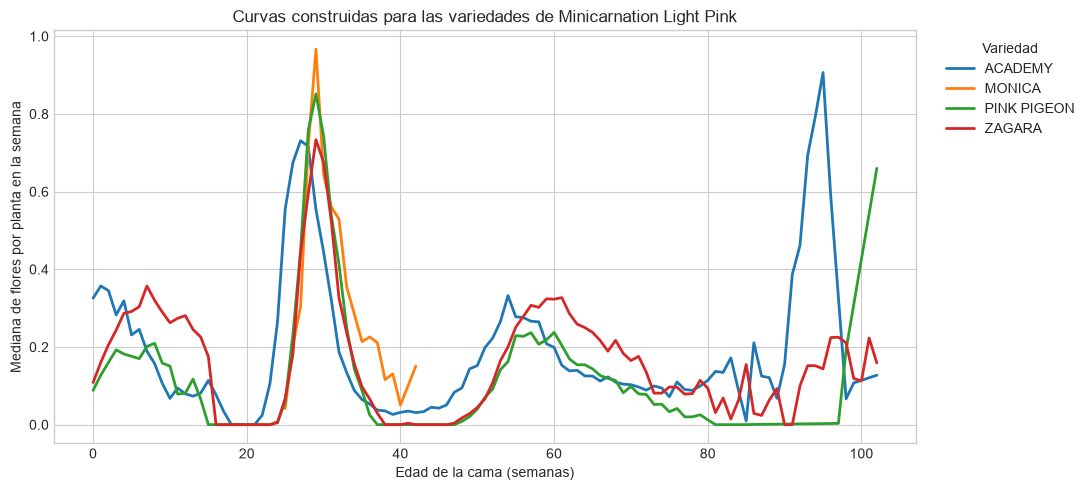

In [23]:
# REFERENCIA DOCUMENTAL. No ejecutar como pipeline.
# fig, ax = plt.subplots(figsize=(11, 5))
# for variedad, datos in perfil.groupby("k_variedad"):
#     datos = datos.sort_values("edad_semana")
#     ax.plot(datos["edad_semana"], datos["flores_planta_semana"], label=variedad, linewidth=2)
# 
# ax.set(
#     title="Curvas construidas para las variedades de Minicarnation Light Pink",
#     xlabel="Edad de la cama (semanas)",
#     ylabel="Mediana de flores por planta en la semana",
# )
# ax.legend(title="Variedad", bbox_to_anchor=(1.02, 1), loc="upper left")
# plt.tight_layout()
# plt.show()


### Resumen del recorrido

1. El Excel es la fuente cruda.
2. El notebook 01 extrae `Base de datos` y `Camas Piloto` a CSV limpios, conservando la fila original.
3. Las referencias se normalizan para relacionar producción semanal con cama y plantas.
4. Los ambiguos y sin match se conservan y se señalan; no se asignan arbitrariamente.
5. Los `N/D` y nulos no se convierten en cero.
6. Solo las filas con variedad, edad y flores por planta válidas entran al `groupby`.
7. El `groupby` produce la curva consolidada por variedad y edad.
8. Esa curva se aplica cama por cama en el punto 4.


## 4. Producción teórica, cama por cama

Para cada cama se aplica exactamente esta fórmula:

\[
	ext{tallos teóricos de la cama} = 	ext{plantas de la cama} 	imes 	ext{flores/planta de su variedad y edad}
\]

Las camas sin un punto de curva compatible se conservan como faltantes y **no se convierten en cero**. La cobertura indica qué porcentaje de plantas sí pudo calcularse.


In [24]:
# REFERENCIA DOCUMENTAL. No ejecutar como pipeline.
# detalle_teorico = camas_color.merge(
#     perfil, on=["k_variedad", "edad_semana"], how="left", validate="many_to_one"
# )
# detalle_teorico["tallos_teoricos"] = detalle_teorico["plantas"] * detalle_teorico["flores_planta_semana"]
# 
# plantas_totales = detalle_teorico["plantas"].sum()
# plantas_con_curva = detalle_teorico.loc[detalle_teorico["flores_planta_semana"].notna(), "plantas"].sum()
# cobertura_pct = 100 * plantas_con_curva / plantas_totales if plantas_totales else np.nan
# tallos_teoricos = detalle_teorico["tallos_teoricos"].sum(min_count=1)
# 
# resumen_variedad = (
#     detalle_teorico.groupby("k_variedad", as_index=False)
#     .agg(camas=("nro_cama", "size"), plantas=("plantas", "sum"),
#          plantas_con_curva=("flores_planta_semana", lambda x: detalle_teorico.loc[x.index[x.notna()], "plantas"].sum()),
#          tallos_teoricos=("tallos_teoricos", "sum"))
#     .sort_values("tallos_teoricos", ascending=False)
# )
# resumen_variedad["cobertura_plantas_pct"] = 100 * resumen_variedad["plantas_con_curva"] / resumen_variedad["plantas"]
# 
# print(f"Producción teórica total: {tallos_teoricos:,.0f} tallos")
# print(f"Cobertura de la curva: {cobertura_pct:.1f}% de las plantas")
# display(resumen_variedad)
# display(detalle_teorico[["invernadero", "nro_cama", "variedad", "plantas", "edad_semana",
#                          "flores_planta_semana", "tallos_teoricos"]].head(12))


Producción teórica total: 99,807 tallos
Cobertura de la curva: 99.7% de las plantas


,k_variedad,camas,plantas,plantas_con_curva,tallos_teoricos,cobertura_plantas_pct
0,ACADEMY,248,"305,702.00","305,702.00","54,106.84",100.00
6,ZAGARA,113,"135,115.00","135,115.00","25,508.45",100.00
4,PINK PIGEON,100,"118,930.00","118,930.00","20,192.05",100.00
2,NEW ROXANNE,1,138.00,0.00,0.00,0.00
1,MONICA,1,"1,200.00",0.00,0.00,0.00
3,OPERETA,1,102.00,0.00,0.00,0.00
5,PROMISE,1,200.00,0.00,0.00,0.00


,invernadero,nro_cama,variedad,plantas,edad_semana,flores_planta_semana,tallos_teoricos
0,Bloque 01,203.00,Zagara,"1,200.00",67,0.19,227.00
1,Bloque 01,205.00,Zagara,"1,200.00",67,0.19,227.00
2,Bloque 01,124.00,Pink Pigeon,"1,296.00",70,0.10,127.44
3,Bloque 01,173.00,Pink Pigeon,"1,200.00",68,0.11,136.41
4,Bloque 01,125.00,Pink Pigeon,"1,200.00",70,0.10,118.00
5,Bloque 02,117.00,Pink Pigeon,"1,176.00",47,0.00,0.00
6,Bloque 02,134.00,Zagara,"1,236.00",47,0.00,4.83
7,Bloque 02,136.00,Zagara,"1,236.00",47,0.00,4.83
8,Bloque 02,132.00,Zagara,"1,236.00",47,0.00,4.83
9,Bloque 02,206.00,Pink Pigeon,"1,158.00",46,0.00,0.00


## 5. Recuperar el estimado manual del ingeniero

Se recorren las bases limpias de estimados y se selecciona el envío que **empieza en la semana objetivo**. En estos Excel, `horizonte = 1` es la propia semana inicial del archivo. Esta convención es distinta de llamar `+1` a la semana siguiente; por eso la comparación se alinea por **año y semana objetivo**, no solo por el número de horizonte.


In [25]:
# REFERENCIA DOCUMENTAL. No ejecutar como pipeline.
# carpeta_estimados = DATOS_EJ / "Estimados semanales" / "datos preprocesados" / "archivos"
# columnas_estimado = ["archivo_origen", "semana_inicio_archivo", "finca", "producto", "color",
#                      "variedad", "tipo", "anio_objetivo", "semana_objetivo", "horizonte", "tallos"]
# partes = []
# for ruta in carpeta_estimados.glob("*.csv"):
#     try:
#         parte = pd.read_csv(ruta, usecols=columnas_estimado, low_memory=False)
#     except (ValueError, UnicodeDecodeError):
#         continue
#     mascara = (
#         parte["finca"].map(clave).eq("GAITANA")
#         & parte["producto"].map(clave).eq(PRODUCTO_EJ)
#         & parte["color"].map(clave).eq(COLOR_EJ)
#         & parte["tipo"].map(clave).eq("ESTIMADO")
#     )
#     if mascara.any():
#         partes.append(parte.loc[mascara].copy())
# 
# estimados_color = pd.concat(partes, ignore_index=True)
# for col in ["semana_inicio_archivo", "anio_objetivo", "semana_objetivo", "horizonte", "tallos"]:
#     estimados_color[col] = pd.to_numeric(estimados_color[col], errors="coerce")
# 
# manual_semana = estimados_color[
#     estimados_color["anio_objetivo"].eq(ANIO_OBJETIVO)
#     & estimados_color["semana_objetivo"].eq(SEMANA_OBJETIVO)
#     & estimados_color["semana_inicio_archivo"].eq(SEMANA_OBJETIVO)
# ].copy()
# 
# if manual_semana.empty:
#     raise ValueError("No se encontró el estimado manual emitido para la semana objetivo")
# 
# # Una sola emisión puede contener varias filas/variedades; se suman para obtener el color.
# archivo_manual = manual_semana["archivo_origen"].iloc[-1]
# manual_semana = manual_semana[manual_semana["archivo_origen"].eq(archivo_manual)]
# tallos_ingeniero = manual_semana["tallos"].sum()
# 
# print(f"Archivo manual: {archivo_manual}")
# print(f"Estimado del ingeniero: {tallos_ingeniero:,.0f} tallos")
# display(manual_semana.groupby("variedad", as_index=False)["tallos"].sum().sort_values("tallos", ascending=False))


Archivo manual: Estimado Sem 31-35 2026 Gaitana-Arabella.xlsx
Estimado del ingeniero: 76,150 tallos


,variedad,tallos
0,Academy,"44,740.00"
2,Zagara,"16,700.00"
1,Pink Pigeon,"14,710.00"


## 6. Benchmark de la última semana: teórico vs. ingeniero vs. real

- **Error = pronóstico − real.** Positivo significa sobreestimación; negativo, subestimación.
- **Error absoluto** mide cuántos tallos se fallaron sin importar la dirección.
- **APE** expresa ese error como porcentaje del volumen real de esta semana.

Este cuadro compara métodos; no suma ni mezcla sus valores.


,método,pronóstico_tallos,real_tallos,error_tallos,error_absoluto,APE_pct
0,Curva teórica,"99,807.34","77,611.00","22,196.34","22,196.34",28.60
1,Ingeniero,"76,150.00","77,611.00","-1,461.00","1,461.00",1.88


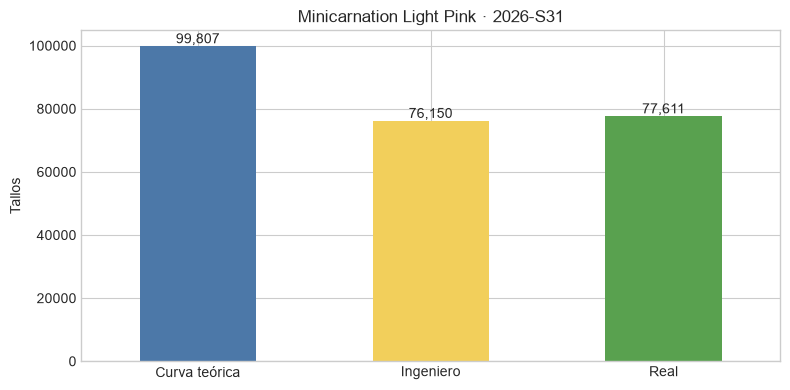

In [26]:
# REFERENCIA DOCUMENTAL. No ejecutar como pipeline.
# comparacion_semana = pd.DataFrame({
#     "método": ["Curva teórica", "Ingeniero"],
#     "pronóstico_tallos": [tallos_teoricos, tallos_ingeniero],
# })
# comparacion_semana["real_tallos"] = tallos_reales
# comparacion_semana["error_tallos"] = comparacion_semana["pronóstico_tallos"] - tallos_reales
# comparacion_semana["error_absoluto"] = comparacion_semana["error_tallos"].abs()
# comparacion_semana["APE_pct"] = 100 * comparacion_semana["error_absoluto"] / tallos_reales if tallos_reales else np.nan
# display(comparacion_semana)
# 
# grafica = pd.DataFrame({
#     "fuente": ["Curva teórica", "Ingeniero", "Real"],
#     "tallos": [tallos_teoricos, tallos_ingeniero, tallos_reales],
# })
# ax = grafica.plot.bar(x="fuente", y="tallos", legend=False, figsize=(8, 4),
#                       color=["#4C78A8", "#F2CF5B", "#59A14F"])
# ax.set(title=f"Minicarnation Light Pink · {ANIO_OBJETIVO}-S{SEMANA_OBJETIVO:02d}",
#        xlabel="", ylabel="Tallos")
# ax.bar_label(ax.containers[0], fmt="{:,.0f}")
# plt.xticks(rotation=0)
# plt.tight_layout()
# plt.show()


## 7. Benchmark histórico del estimado manual

Una sola semana sirve para entender el cálculo, pero no para concluir qué método es mejor. Como contexto, se evalúan todas las emisiones disponibles del ingeniero para este mismo producto-color usando la versión de **horizonte 1** y la producción real correspondiente.

Para evitar duplicados, la unidad es:

`archivo de emisión + año objetivo + semana objetivo + producto + color`.

Las métricas principales son:

- **MAE:** error absoluto promedio en tallos por semana;
- **WAPE:** suma de errores absolutos / suma de producción real;
- **sesgo:** error promedio con signo;
- **cobertura:** semanas estimadas que encontraron producción real.


,emisiones h1,pares con real,cobertura_pct,MAE_tallos,WAPE_pct,sesgo_tallos
0,145,142,97.93,"12,337.61",14.15,"-2,691.51"


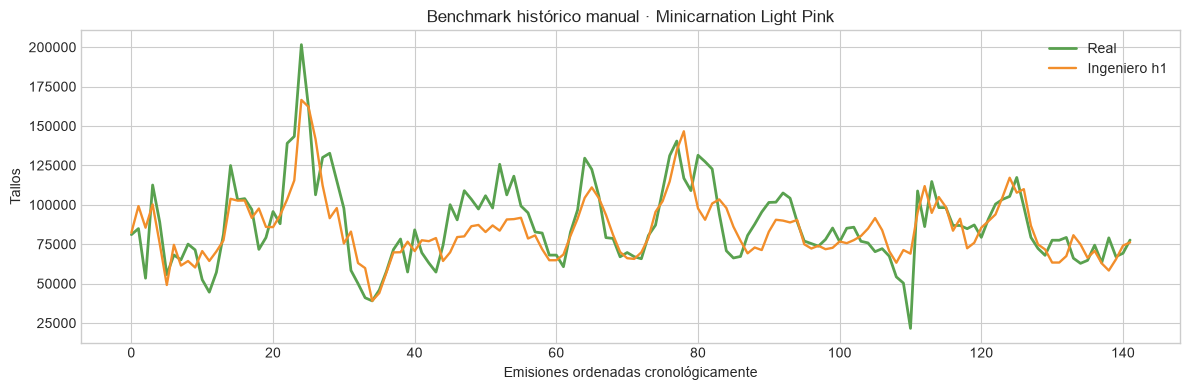

In [27]:
# REFERENCIA DOCUMENTAL. No ejecutar como pipeline.
# manual_h1 = estimados_color[estimados_color["horizonte"].eq(1)].copy()
# manual_h1 = (manual_h1.groupby(["archivo_origen", "anio_objetivo", "semana_objetivo"], as_index=False)
#              .agg(tallos_ingeniero=("tallos", "sum")))
# 
# real_hist = (real[
#     real["k_producto"].map(clave).eq(PRODUCTO_EJ)
#     & real["k_color"].map(clave).eq(COLOR_EJ)
# ].groupby(["anio", "semana"], as_index=False).agg(tallos_reales=("tallos_reales", "sum")))
# 
# benchmark_manual = manual_h1.merge(
#     real_hist, left_on=["anio_objetivo", "semana_objetivo"],
#     right_on=["anio", "semana"], how="left", validate="many_to_one"
# )
# benchmark_manual["error"] = benchmark_manual["tallos_ingeniero"] - benchmark_manual["tallos_reales"]
# benchmark_manual["error_abs"] = benchmark_manual["error"].abs()
# pares = benchmark_manual.dropna(subset=["tallos_reales"]).copy()
# 
# metricas_manual = pd.DataFrame({
#     "emisiones h1": [len(benchmark_manual)],
#     "pares con real": [len(pares)],
#     "cobertura_pct": [100 * len(pares) / len(benchmark_manual) if len(benchmark_manual) else np.nan],
#     "MAE_tallos": [pares["error_abs"].mean()],
#     "WAPE_pct": [100 * pares["error_abs"].sum() / pares["tallos_reales"].sum()],
#     "sesgo_tallos": [pares["error"].mean()],
# })
# display(metricas_manual)
# 
# serie = pares.sort_values(["anio_objetivo", "semana_objetivo"])
# fig, ax = plt.subplots(figsize=(12, 4))
# ax.plot(range(len(serie)), serie["tallos_reales"], label="Real", color="#59A14F", linewidth=2)
# ax.plot(range(len(serie)), serie["tallos_ingeniero"], label="Ingeniero h1", color="#F28E2B", linewidth=1.7)
# ax.set(title="Benchmark histórico manual · Minicarnation Light Pink",
#        xlabel="Emisiones ordenadas cronológicamente", ylabel="Tallos")
# ax.legend()
# plt.tight_layout()
# plt.show()


## 8. Lectura final y límites

La comparación de la semana responde **qué valor quedó más cerca del real**, no por qué ocurrió la diferencia. La producción teórica representa lo esperable según plantas, variedad y edad; el ingeniero puede incorporar información operativa no contenida en la curva.

Antes de interpretar el resultado revise siempre:

1. **Cobertura de plantas con curva:** una cobertura baja hace incompleto el total teórico.
2. **Semana alineada:** aquí los tres valores pertenecen exactamente al mismo año-semana ISO.
3. **Camas faltantes o edades fuera de rango:** quedan como `NaN`, nunca como producción cero.
4. **Una semana no demuestra superioridad:** el benchmark histórico aporta contexto para el ingeniero; una evaluación histórica equivalente de la curva exige reconstruir cada fotografía semanal sin fuga temporal.

### En una frase

Para este color, el pronóstico teórico nace de sumar `plantas de cada cama × curva de su variedad a su edad`; después se contrasta, sin mezclarlo, con el juicio del ingeniero y con los tallos realmente cosechados.
